In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = '/path/data'

## plot method

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.gridspec as gridspec

def plot_box_multik(df, tis, state):
    # Create a tall figure to accommodate 2 sets (Top-10, 50) of mirrored reflection plots
    fig = plt.figure(figsize=(14, 10)) 
    
    outer_gs = gridspec.GridSpec(2, 1, hspace=0.15, height_ratios=[2.0, 1.0]) 
        
    x_positions = range(len(df['dis'].unique()))
    dis_vals = sorted(df['dis'].unique())
    x_labels = [f'{int(d/1e5)}e5' for d in dis_vals]

    # Define color palette logically grouped by metric
    # Recall colors: Perturbation (Blue), Correlation (Red)
    pal_rec = ["#7091DD", "#FF4F4F"] 
    # Precision colors: Perturbation (Green), Correlation (Orange)
    pal_prec = ['#66C2A5', "#FC8D62"]
    
    ks = [10, 50]
    
    for idx, k in enumerate(ks):
        # Inner GridSpec: split each group into top and bottom panels with zero vertical spacing
        inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[idx], hspace=0.0)
        ax_top = fig.add_subplot(inner_gs[0])
        ax_bot = fig.add_subplot(inner_gs[1], sharex=ax_top)
        
        # ---------- 1. Dynamically generate corresponding Melt DataFrame ----------
        val_vars = [f'top{k}_prec', f'top{k}_rec', f'preds_top{k}_prec', f'preds_top{k}_rec']
        df_melt = pd.melt(df, 
                            id_vars=['dis', 'gene_name'], 
                            value_vars=val_vars, 
                            var_name='metrics', 
                            value_name='binary')
        
        df_melt['metrics'] = df_melt['metrics'].map({
            f'top{k}_prec': 'Perturbation Precision',
            f'top{k}_rec': 'Perturbation Recall',
            f'preds_top{k}_prec': 'Correlation Precision',
            f'preds_top{k}_rec': 'Correlation Recall'
        })
        
        # Split data by Recall (Top panel) and Precision (Bottom panel)
        df_melt_rec = df_melt[df_melt['metrics'].isin(['Perturbation Recall', 'Correlation Recall'])]
        df_melt_prec = df_melt[df_melt['metrics'].isin(['Perturbation Precision', 'Correlation Precision'])]
        
        # ---------- 2. Calculate means for each distance interval ----------
        mean_prec = df.groupby('dis')[f'top{k}_prec'].mean().values
        mean_rec = df.groupby('dis')[f'top{k}_rec'].mean().values
        preds_mean_prec = df.groupby('dis')[f'preds_top{k}_prec'].mean().values
        preds_mean_rec = df.groupby('dis')[f'preds_top{k}_rec'].mean().values

        # ==================== Top Panel: Recall ====================
        if not df_melt_rec.empty:
            sns.boxplot(data=df_melt_rec, x='dis', y='binary', hue='metrics',
                        palette=pal_rec, width=0.6, ax=ax_top, gap=0.15,
                        hue_order=['Perturbation Recall', 'Correlation Recall'])

        # Left (-0.15): Perturbation Recall | Right (+0.15): Correlation Recall
        ax_top.scatter([x - 0.15 for x in x_positions], mean_rec, color='darkblue', s=100, marker='s', label='Mean Recall (Perturb)', zorder=5)
        ax_top.scatter([x + 0.15 for x in x_positions], preds_mean_rec, color='#990000', s=100, marker='s', label='Mean Recall (Corr)', zorder=5)

        if idx == 0:
            ax_top.set_ylim(0, 1.1) 
            ax_top.set_ylabel('Recall', fontsize=26)
        else:
            ax_top.set_ylim(0.5, 1.1) 
            ax_top.set_ylabel(None)
        ax_top.set_xlabel('') 
        
        ax_top.set_title(f'Score@{k} for {state} in {tis} (10kb merger)', fontsize=28)

        # ==================== Bottom Panel: Precision ====================
        if not df_melt_prec.empty:
            sns.boxplot(data=df_melt_prec, x='dis', y='binary', hue='metrics',
                        palette=pal_prec, width=0.6, ax=ax_bot, gap=0.15,
                        hue_order=['Perturbation Precision', 'Correlation Precision'])

        # Left (-0.15): Perturbation Precision | Right (+0.15): Correlation Precision
        ax_bot.scatter([x - 0.15 for x in x_positions], mean_prec, color='darkgreen', s=100, marker='s', label='Mean Precision (Perturb)', zorder=5)
        ax_bot.scatter([x + 0.15 for x in x_positions], preds_mean_prec, color='#B33900', s=100, marker='s', label='Mean Precision (Corr)', zorder=5)

        
        if idx == 0:
            ax_bot.set_ylim(0, 1.1)
            ax_bot.set_ylabel('Precision', fontsize=26)
        else:
            ax_bot.set_ylim(0, 0.6)
            ax_bot.set_ylabel(None)
        
        # ==================== Legend & Formatting ====================
        if idx == 0:
            # Top Panel Legend (Recall)
            handles_top, labels_top = ax_top.get_legend_handles_labels()
            c_handles_top, c_labels_top = [], []
            for h, l in zip(handles_top, labels_top):
                if l not in c_labels_top and l != 'metrics':
                    c_handles_top.append(h)
                    c_labels_top.append(l)
            ax_top.legend(c_handles_top, c_labels_top, loc='upper right', fontsize=16, ncol=2, framealpha=0.9)
            # ax_top.get_legend().remove()
            
            # Bottom Panel Legend (Precision)
            handles_bot, labels_bot = ax_bot.get_legend_handles_labels()
            c_handles_bot, c_labels_bot = [], []
            for h, l in zip(handles_bot, labels_bot):
                if l not in c_labels_bot and l != 'metrics':
                    c_handles_bot.append(h)
                    c_labels_bot.append(l)
            ax_bot.legend(c_handles_bot, c_labels_bot, loc='upper right', fontsize=16, ncol=2, framealpha=0.9)
            # ax_bot.get_legend().remove()
        else:
            if ax_top.get_legend() is not None:
                ax_top.get_legend().remove()
            if ax_bot.get_legend() is not None:
                ax_bot.get_legend().remove()

        for ax in [ax_top, ax_bot]:
            for spine in ax.spines.values():
                spine.set_linewidth(2)
            ax.tick_params(axis='both', which='major', labelsize=20)
            
        # Show x-axis labels only on the very bottom plot
        if idx == len(ks) - 1:
            ax_bot.set_xticks(x_positions)
            ax_bot.set_xticklabels(x_labels)
            ax_bot.set_xlabel('Distance from gene (bp)', fontsize=26)
        else:
            ax_bot.set_xlabel('')
            ax_bot.tick_params(labelbottom=False)
            
    plt.tight_layout()
    plt.savefig(data_dir + f'/perturbation_tumor/gene_peak_figs/gene_peak_regulation_top_gene_{tis}_{state}_top_merge.pdf', format='pdf', dpi=300)
    plt.show()

## binary method

In [ ]:
def plot_box_binary(df, df_melt, tis, state):
    # Create top and bottom subplots with no vertical spacing
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={'hspace': 0, 'height_ratios': [1.05, 1.05]})

    # Calculate means (based on the original df)
    mean_mcc = df.groupby('dis')['mcc'].mean().values
    mean_f1 = df.groupby('dis')['f1'].mean().values
    preds_mean_mcc = df.groupby('dis')['preds_mcc'].mean().values
    preds_mean_f1 = df.groupby('dis')['preds_f1'].mean().values

    x_positions = range(len(mean_mcc))
    dis_vals = sorted(df['dis'].unique())
    x_labels = [f'{int(d/1e5)}e5' for d in dis_vals]

    # ==================== Core modification: Split by Metric Type ====================
    # Separate data into F1 and MCC for the top and bottom panels respectively
    df_melt_f1 = df_melt[df_melt['metrics'].isin(['Perturbation F1', 'Correlation F1'])]
    df_melt_mcc = df_melt[df_melt['metrics'].isin(['Perturbation MCC', 'Correlation MCC'])]

    # ==================== Top Panel (ax1): F1 Metrics ====================
    if not df_melt_f1.empty:
        sns.boxplot(data=df_melt_f1, x='dis', y='binary', hue='metrics',
                    palette=["#7091DD", "#FF4F4F"], width=0.6, ax=ax1,
                    hue_order=['Perturbation F1', 'Correlation F1'], gap=0.15) 

    # Scatter and lines for F1
    ax1.scatter([x - 0.15 for x in x_positions], mean_f1, 
                color='darkblue', s=100, marker='s', label='Mean F1 (Perturb)', zorder=5)
    ax1.scatter([x + 0.15 for x in x_positions], preds_mean_f1, 
                color='#990000', s=100, marker='s', label='Mean F1 (Corr)', zorder=5)

    ax1.set_ylim(0, 1.05) 
    ax1.set_ylabel('F1', fontsize=26)
    ax1.set_title(f'{state} in {tis} (10kb merger)', fontsize=28, pad=20)
    ax1.set_xlabel('') 

    # Independent Legend for ax1 (F1)
    handles1, labels1 = ax1.get_legend_handles_labels()
    h1, l1 = [], []
    for h, l in zip(handles1, labels1):
        if l not in l1 and l != 'metrics':
            h1.append(h)
            l1.append(l)
    ax1.legend(h1, l1, loc='lower right', fontsize=18, ncol=2, framealpha=0.9)
    # ax1.get_legend().remove()

    # ==================== Bottom Panel (ax2): MCC Metrics ====================
    if not df_melt_mcc.empty:
        sns.boxplot(data=df_melt_mcc, x='dis', y='binary', hue='metrics',
                    palette=['#66C2A5', '#FC8D62'], width=0.6, ax=ax2,
                    hue_order=['Perturbation MCC', 'Correlation MCC'], gap=0.15)

    # Scatter and lines for MCC
    ax2.scatter([x - 0.15 for x in x_positions], mean_mcc, 
                color='darkgreen', s=100, marker='s', label='Mean MCC (Perturb)', zorder=5)
    ax2.scatter([x + 0.15 for x in x_positions], preds_mean_mcc, 
                color='#B33900', s=100, marker='s', label='Mean MCC (Corr)', zorder=5)

    ax2.set_ylim(0, 1.1)
    ax2.set_ylabel('MCC', fontsize=26)
    ax2.set_xlabel('Distance from gene (bp)', fontsize=26)

    # Independent Legend for ax2 (MCC)
    handles2, labels2 = ax2.get_legend_handles_labels()
    h2, l2 = [], []
    for h, l in zip(handles2, labels2):
        if l not in l2 and l != 'metrics':
            h2.append(h)
            l2.append(l)
    ax2.legend(h2, l2, loc='upper right', fontsize=18, ncol=2, framealpha=0.9)
    # ax2.get_legend().remove()

    # ==================== Axes and Global Styling ====================
    for ax in [ax1, ax2]:
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        ax.tick_params(axis='both', which='major', labelsize=24)
        
    ax2.set_xticks(x_positions)
    ax2.set_xticklabels(x_labels)

    plt.tight_layout()
    plt.savefig(data_dir + f'/perturbation_tumor/gene_peak_figs/gene_peak_regulation_top_gene_{tis}_{state}_mcc_f1_merge.pdf', format='pdf', dpi=300)
    plt.show()

## auprc method

In [ ]:
def plot_box(df, df_melt, tis, state):
    plt.figure(figsize=(14, 6))

    name_mapping = {
        'epiGen': 'epiGen Perturbation',
        'Prediction': 'Correlation',
        'Random': 'Random'
    }
    df_melt['Method'] = df_melt['Method'].map(name_mapping)

    sns.boxplot(data=df_melt, x='dis', y='AUPR', hue='Method',
                palette=['#66C2A5', "#7091DD", '#FC8D62'], width=0.8, gap=0.15)

    mean_aupr_epiGen = df.groupby('dis')['epiGen_aupr'].mean()
    mean_aupr_preds = df.groupby('dis')['preds_aupr'].mean()
    mean_aupr_random = df.groupby('dis')['random_aupr'].mean()

    x_positions = range(len(mean_aupr_epiGen))
    plt.scatter([x - 0.27 for x in x_positions], mean_aupr_epiGen, 
                color='darkgreen', s=100, marker='s', label='Mean epiGen Perturbation', zorder=5)
    plt.scatter([x for x in x_positions], mean_aupr_preds, 
                color='darkblue', s=100, marker='s', label='Mean Correlation', zorder=5)
    plt.scatter([x + 0.27 for x in x_positions], mean_aupr_random, 
                color='darkred', s=100, marker='s', label='Mean Random', zorder=5)

    ax = plt.gca()
    dis_vals = sorted(df['dis'].unique())
    ax.set_xticklabels([f'{int(d/1e5)}e5' for d in dis_vals])
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    plt.xlabel('Distance from gene (bp)', fontsize=22)
    plt.ylabel('AUPRC', fontsize=22)
    plt.title(f'{state} in {tis} (10kb merger)', fontsize=24, pad=20)
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=22)
    plt.ylim(0, 1.0)
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)

    plt.tight_layout()
    plt.savefig(data_dir + f'/perturbation_tumor/gene_peak_figs/gene_peak_regulation_top_gene_{tis}_{state}_merge.pdf', format='pdf', dpi=300)
    plt.show()

## tumor

In [32]:
tis = 'pancreas'

/tmp/ipykernel_761291/2649290574.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{int(d/1e5)}e5' for d in dis_vals])


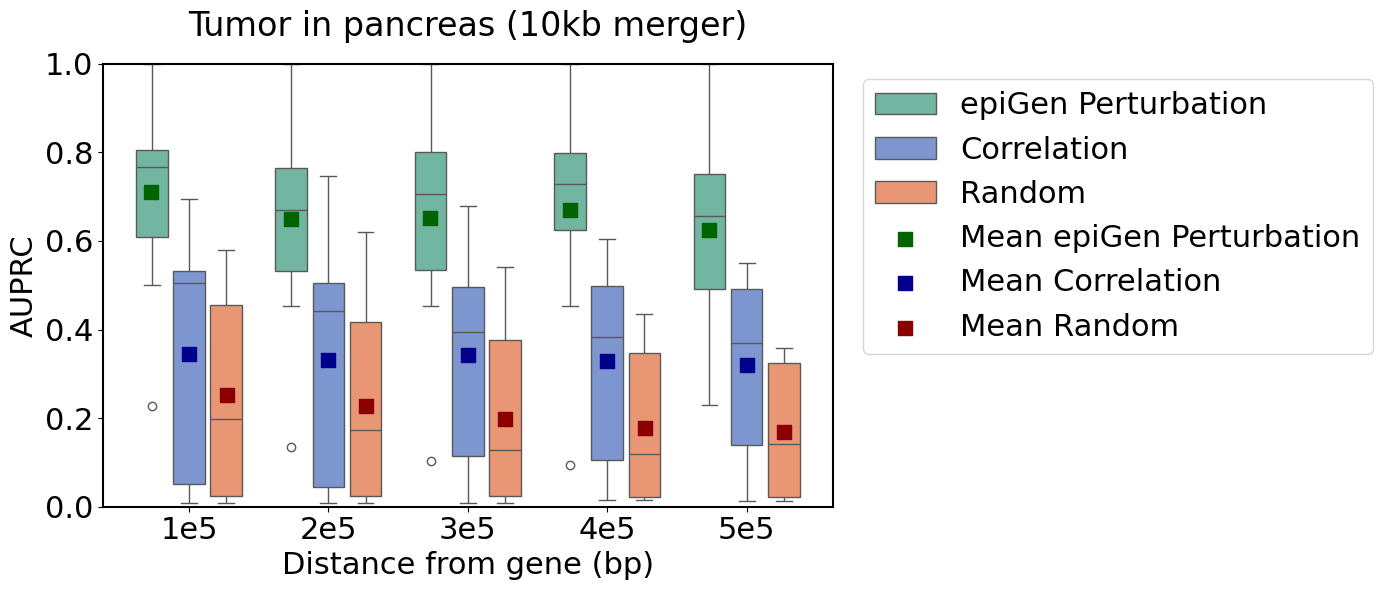

In [9]:
state = 'Tumor'
df = pd.read_csv(data_dir + f"/perturbation_tumor/gene_peak_nearby_merge/{tis}_nearby_aupr_{state}_permutation_10000_end.csv", index_col=0).iloc[:, :25]
df.columns = ['dis', 'gene_name', 'epiGen_aupr', 'auroc', 'mcc', 'f1', 
              'top10_prec', 'top50_prec', 'top100_prec', 'top10_rec', 'top50_rec', 'top100_rec', 
              'preds_auroc', 'preds_aupr', 'preds_mcc', 'preds_f1', 
              'preds_top10_prec', 'preds_top50_prec', 'preds_top100_prec', 'preds_top10_rec', 'preds_top50_rec', 'preds_top100_rec', 
              'n_total_peaks', 'n_positive_peaks', 'random_aupr']
original_gene_order = df['gene_name'].unique().tolist()
df['gene_name'] = pd.Categorical(df['gene_name'], categories=original_gene_order, ordered=True)
df = df.sort_values(['gene_name', 'dis'], ascending=[True, True])
df_melt = pd.melt(df, 
                  id_vars=['dis', 'gene_name'],
                  value_vars=['epiGen_aupr', 'preds_aupr', 'random_aupr'],
                  var_name='Method',
                  value_name='AUPR')

df_melt['Method'] = df_melt['Method'].map({
    'epiGen_aupr': 'epiGen',
    'preds_aupr': 'Prediction',
    'random_aupr': 'Random'
})

plot_box(df, df_melt, tis, state)

## tumor top

/tmp/ipykernel_761291/412772626.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


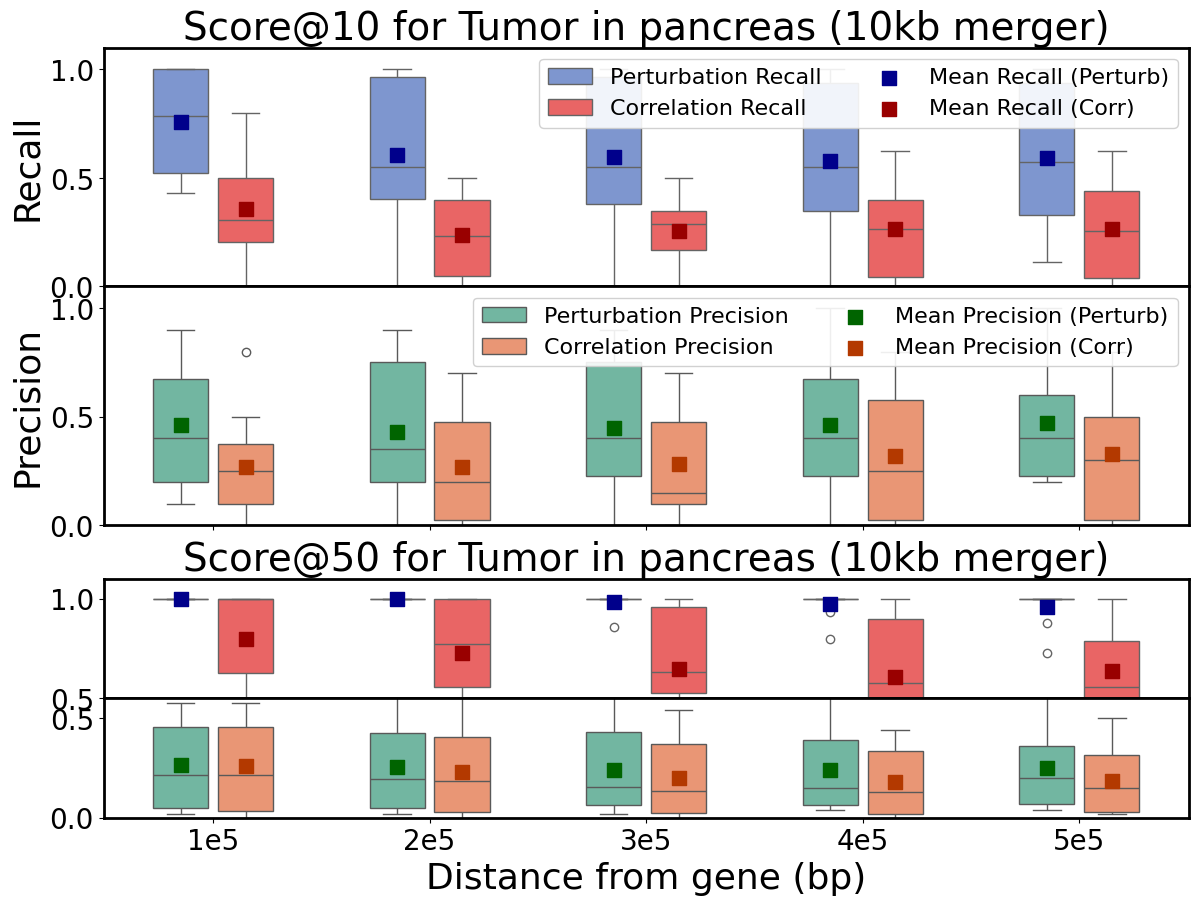

In [35]:
state = 'Tumor'
df = pd.read_csv(data_dir + f"/perturbation_tumor/gene_peak_nearby_merge/{tis}_nearby_aupr_{state}_permutation_10000_end.csv", index_col=0).iloc[:, :25]
df.columns = ['dis', 'gene_name', 'epiGen_aupr', 'auroc', 'mcc', 'f1', 
              'top10_prec', 'top50_prec', 'top100_prec', 'top10_rec', 'top50_rec', 'top100_rec', 
              'preds_auroc', 'preds_aupr', 'preds_mcc', 'preds_f1', 
              'preds_top10_prec', 'preds_top50_prec', 'preds_top100_prec', 'preds_top10_rec', 'preds_top50_rec', 'preds_top100_rec', 
              'n_total_peaks', 'n_positive_peaks', 'random_aupr']

original_gene_order = df['gene_name'].unique().tolist()
df['gene_name'] = pd.Categorical(df['gene_name'], categories=original_gene_order, ordered=True)
df = df.sort_values(['gene_name', 'dis'], ascending=[True, True])
plot_box_multik(df, tis, state)

## tumor binary

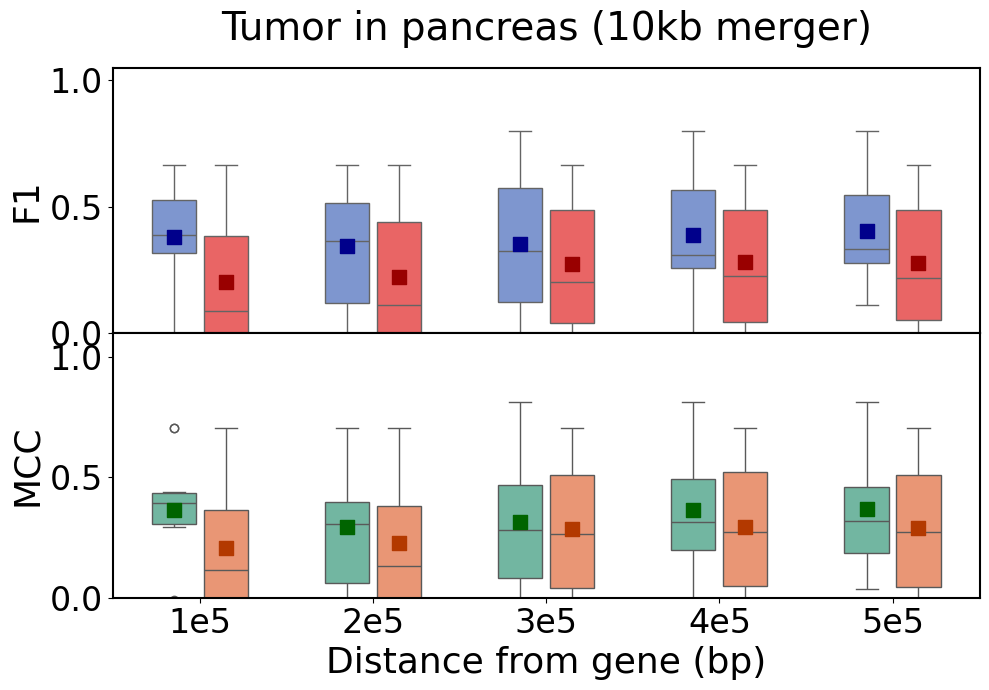

In [33]:
state = 'Tumor'
df = pd.read_csv(data_dir + f"/perturbation_tumor/gene_peak_nearby_merge/{tis}_nearby_aupr_{state}_permutation_10000_end.csv", index_col=0).iloc[:, :25]
df.columns = ['dis', 'gene_name', 'epiGen_aupr', 'auroc', 'mcc', 'f1', 
              'top10_prec', 'top50_prec', 'top100_prec', 'top10_rec', 'top50_rec', 'top100_rec', 
              'preds_auroc', 'preds_aupr', 'preds_mcc', 'preds_f1', 
              'preds_top10_prec', 'preds_top50_prec', 'preds_top100_prec', 'preds_top10_rec', 'preds_top50_rec', 'preds_top100_rec', 
              'n_total_peaks', 'n_positive_peaks', 'random_aupr']
original_gene_order = df['gene_name'].unique().tolist()
df['gene_name'] = pd.Categorical(df['gene_name'], categories=original_gene_order, ordered=True)
df = df.sort_values(['gene_name', 'dis'], ascending=[True, True])
df_melt = pd.melt(df, 
                  id_vars=['dis', 'gene_name'],
                  value_vars=['mcc', 'f1', 'preds_mcc', 'preds_f1'],
                  var_name='metrics',
                  value_name='binary')
df_melt['metrics'] = df_melt['metrics'].map({
    'mcc': 'Perturbation MCC',
    'f1': 'Perturbation F1',
    'preds_mcc': 'Correlation MCC',
    'preds_f1': 'Correlation F1'
})

plot_box_binary(df, df_melt, tis, state)

## normal

/tmp/ipykernel_761291/2649290574.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{int(d/1e5)}e5' for d in dis_vals])


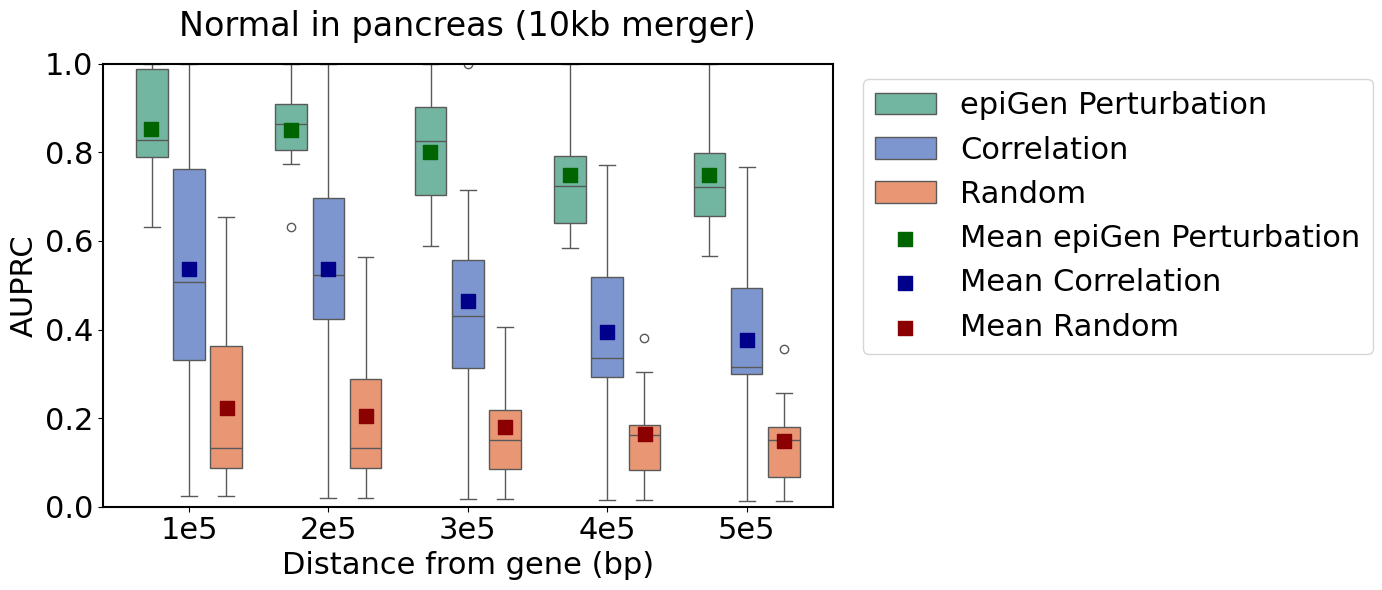

In [14]:
state = 'Normal'
df = pd.read_csv(data_dir + f"/perturbation_tumor/gene_peak_nearby_merge/{tis}_nearby_aupr_{state}_permutation_10000_end.csv", index_col=0).iloc[:, :25]
df.columns = ['dis', 'gene_name', 'epiGen_aupr', 'auroc', 'mcc', 'f1', 
              'top10_prec', 'top50_prec', 'top100_prec', 'top10_rec', 'top50_rec', 'top100_rec', 
              'preds_auroc', 'preds_aupr', 'preds_mcc', 'preds_f1', 
              'preds_top10_prec', 'preds_top50_prec', 'preds_top100_prec', 'preds_top10_rec', 'preds_top50_rec', 'preds_top100_rec', 
              'n_total_peaks', 'n_positive_peaks', 'random_aupr']
original_gene_order = df['gene_name'].unique().tolist()
df['gene_name'] = pd.Categorical(df['gene_name'], categories=original_gene_order, ordered=True)
df = df.sort_values(['gene_name', 'dis'], ascending=[True, True])
df_melt = pd.melt(df, 
                  id_vars=['dis', 'gene_name'],
                  value_vars=['epiGen_aupr', 'preds_aupr', 'random_aupr'],
                  var_name='Method',
                  value_name='AUPR')

df_melt['Method'] = df_melt['Method'].map({
    'epiGen_aupr': 'epiGen',
    'preds_aupr': 'Prediction',
    'random_aupr': 'Random'
})

plot_box(df, df_melt, tis, state)

## normal top

/tmp/ipykernel_761291/3254489160.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


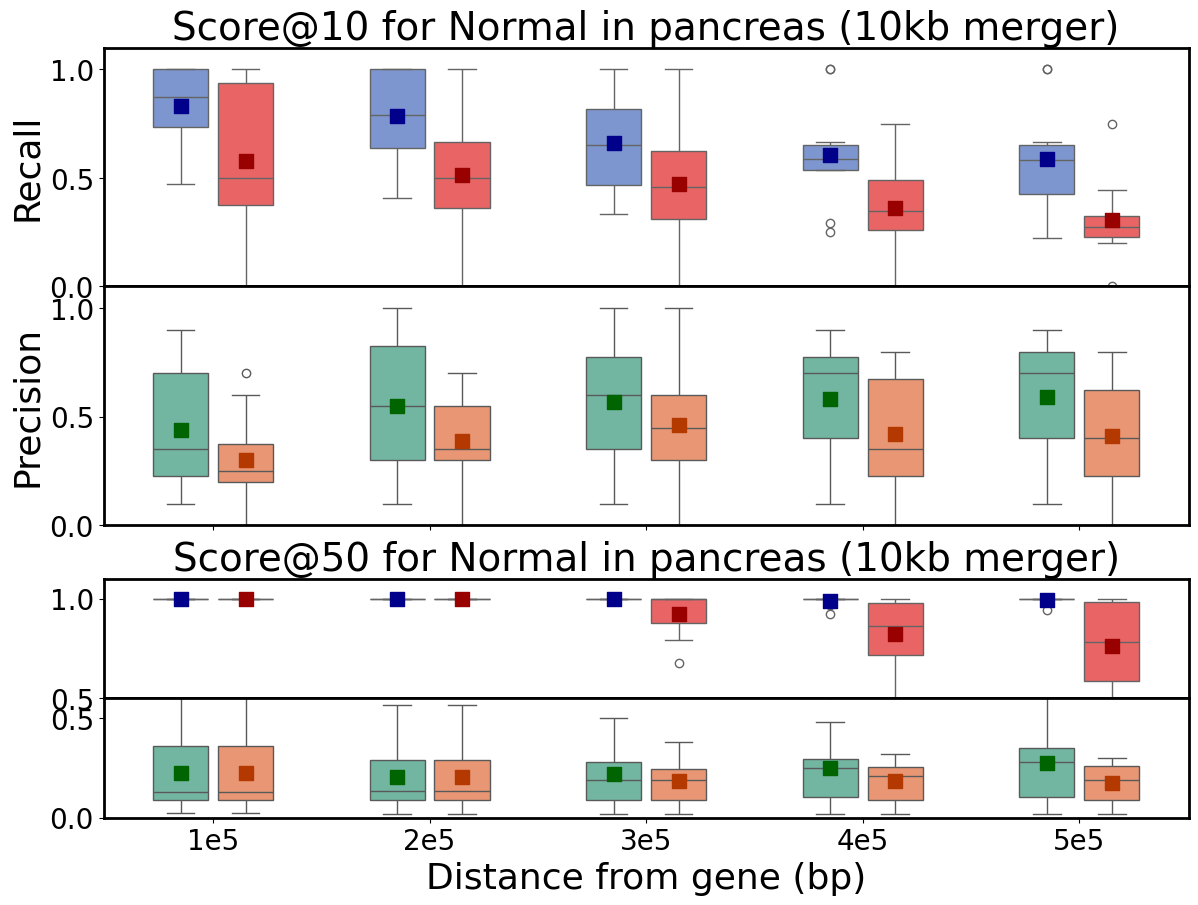

In [16]:
state = 'Normal'
df = pd.read_csv(data_dir + f"/perturbation_tumor/gene_peak_nearby_merge/{tis}_nearby_aupr_{state}_permutation_10000_end.csv", index_col=0).iloc[:, :25]
df.columns = ['dis', 'gene_name', 'epiGen_aupr', 'auroc', 'mcc', 'f1', 
              'top10_prec', 'top50_prec', 'top100_prec', 'top10_rec', 'top50_rec', 'top100_rec', 
              'preds_auroc', 'preds_aupr', 'preds_mcc', 'preds_f1', 
              'preds_top10_prec', 'preds_top50_prec', 'preds_top100_prec', 'preds_top10_rec', 'preds_top50_rec', 'preds_top100_rec', 
              'n_total_peaks', 'n_positive_peaks', 'random_aupr']

original_gene_order = df['gene_name'].unique().tolist()
df['gene_name'] = pd.Categorical(df['gene_name'], categories=original_gene_order, ordered=True)
df = df.sort_values(['gene_name', 'dis'], ascending=[True, True])
plot_box_multik(df, tis, state)

## normal binary

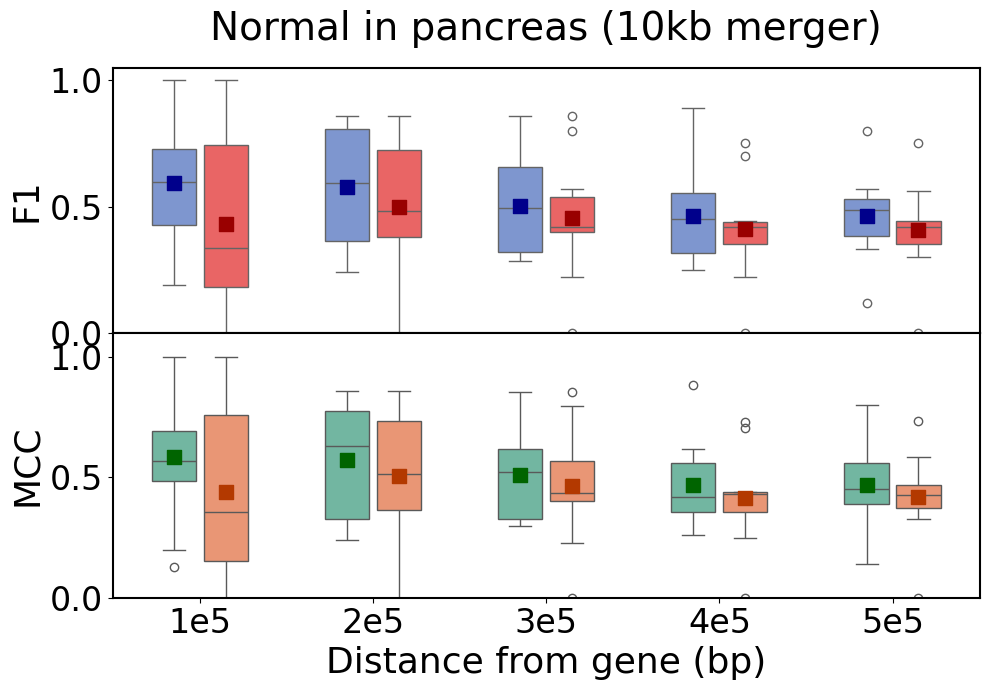

In [17]:
state = 'Normal'
df = pd.read_csv(data_dir + f"/perturbation_tumor/gene_peak_nearby_merge/{tis}_nearby_aupr_{state}_permutation_10000_end.csv", index_col=0).iloc[:, :25]
df.columns = ['dis', 'gene_name', 'epiGen_aupr', 'auroc', 'mcc', 'f1', 
              'top10_prec', 'top50_prec', 'top100_prec', 'top10_rec', 'top50_rec', 'top100_rec', 
              'preds_auroc', 'preds_aupr', 'preds_mcc', 'preds_f1', 
              'preds_top10_prec', 'preds_top50_prec', 'preds_top100_prec', 'preds_top10_rec', 'preds_top50_rec', 'preds_top100_rec', 
              'n_total_peaks', 'n_positive_peaks', 'random_aupr']
original_gene_order = df['gene_name'].unique().tolist()
df['gene_name'] = pd.Categorical(df['gene_name'], categories=original_gene_order, ordered=True)
df = df.sort_values(['gene_name', 'dis'], ascending=[True, True])
df_melt = pd.melt(df, 
                  id_vars=['dis', 'gene_name'],
                  value_vars=['mcc', 'f1', 'preds_mcc', 'preds_f1'],
                  var_name='metrics',
                  value_name='binary')
df_melt['metrics'] = df_melt['metrics'].map({
    'mcc': 'Perturbation MCC',
    'f1': 'Perturbation F1',
    'preds_mcc': 'Correlation MCC',
    'preds_f1': 'Correlation F1'
})

plot_box_binary(df, df_melt, tis, state)